# Proyek Analisis Data: Brazilian E-Commerce Public Dataset (Olist)
- **Nama:** Chamid Bahrul Ulum
- **Email:** ulumcourse@gmail.com
- **ID Dicoding:** cbu-dicoding

## Deskripsi Dataset

Dataset ini merupakan data publik e-commerce Brazil dari platform Olist yang mencakup periode **September 2016 hingga Oktober 2018**. Dataset terdiri dari 9 tabel relasional yang merepresentasikan seluruh perjalanan transaksi, mulai dari pemesanan hingga ulasan pelanggan.

**Tabel-tabel yang digunakan:**
- `orders_dataset.csv` — informasi status dan waktu pesanan
- `order_items_dataset.csv` — detail item dalam setiap pesanan
- `order_payments_dataset.csv` — metode dan nilai pembayaran
- `order_reviews_dataset.csv` — ulasan dan skor kepuasan pelanggan
- `customers_dataset.csv` — informasi dan lokasi pelanggan
- `products_dataset.csv` — atribut produk
- `product_category_name_translation.csv` — terjemahan nama kategori ke bahasa Inggris
- `sellers_dataset.csv` — informasi dan lokasi penjual
- `geolocation_dataset.csv` — koordinat geografis berdasarkan kode pos

## Menentukan Pertanyaan Bisnis

Berdasarkan konteks dataset e-commerce Olist, berikut adalah pertanyaan bisnis yang dirumuskan menggunakan framework **SMART Question**:

---

**Pertanyaan 1:**
> *Bagaimana tren pertumbuhan revenue bulanan platform Olist dan 10 kategori produk apa yang menghasilkan revenue tertinggi sepanjang periode Januari 2017 hingga Agustus 2018?*

- **Specific**: Fokus pada revenue bulanan dan peringkat kategori produk, bukan sekadar jumlah order.
- **Measurable**: Diukur dari total nilai pembayaran (payment_value) dalam satuan BRL per bulan dan per kategori.
- **Action-Oriented**: Hasil analisis dapat digunakan tim bisnis untuk mengalokasikan anggaran promosi pada kategori dan periode dengan performa terbaik.
- **Relevant**: Revenue adalah metrik inti kesehatan bisnis e-commerce.
- **Time-bound**: Dibatasi pada periode Januari 2017 hingga Agustus 2018 untuk menghindari data yang tidak lengkap di awal dan akhir dataset.

---

**Pertanyaan 2:**
> *Bagaimana distribusi skor ulasan pelanggan (review score 1-5) berdasarkan 10 kategori produk dengan volume order tertinggi, dan kategori apa yang memiliki rata-rata kepuasan terendah sepanjang 2017-2018?*

- **Specific**: Fokus pada hubungan antara kategori produk dan skor kepuasan pelanggan.
- **Measurable**: Diukur dari rata-rata review_score dan distribusi per skor per kategori produk.
- **Action-Oriented**: Kategori dengan kepuasan rendah dapat menjadi prioritas untuk perbaikan kualitas produk atau SLA pengiriman.
- **Relevant**: Kepuasan pelanggan berkorelasi langsung dengan retention rate dan reputasi platform.
- **Time-bound**: Dibatasi pada periode 2017-2018 untuk konsistensi dengan pertanyaan pertama.

## CELL 1. Import Semua Packages/Library yang Digunakan

In [1]:
# Library standar untuk manipulasi dan analisis data
import pandas as pd
import numpy as np

# Library untuk visualisasi data
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Library untuk geospatial analysis
import folium
from folium.plugins import HeatMap

# Library untuk tampilan yang lebih baik di notebook
from IPython.display import display, HTML

# Konfigurasi tampilan
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi matplotlib agar plot terlihat bersih dan profesional
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'

# Palet warna konsisten yang akan digunakan sepanjang analisis
COLOR_PRIMARY = '#2E86AB'
COLOR_ACCENT  = '#E84855'
COLOR_NEUTRAL = '#A8A8A8'
COLOR_SUCCESS = '#3BB273'
COLOR_WARNING = '#F4A261'

print('Semua library berhasil diimport.')
print(f'Pandas version : {pd.__version__}')
print(f'NumPy version  : {np.__version__}')

Semua library berhasil diimport.
Pandas version : 2.2.2
NumPy version  : 2.0.2


## CELL 2 Data Wrangling

### Gathering Data

Tahap ini bertujuan mengumpulkan dan memuat seluruh data yang dibutuhkan ke dalam format DataFrame. Dataset terdiri dari 9 file CSV yang saling berelasi, mirip dengan skema database relasional.

#### Setup Dataset via Kaggle

Dataset diunduh langsung dari Kaggle menggunakan `kagglehub`. Cara ini lebih praktis daripada upload manual dan memastikan kamu selalu mendapatkan versi terbaru dataset.

**Syarat**: Perlu memiliki akun Kaggle. Saat pertama kali menjalankan sel di bawah di Colab, kamu akan diminta login ke Kaggle melalui popup OAuth (klik link, izinkan akses, salin kode).

In [4]:
# Install kagglehub (biasanya sudah tersedia di Colab, ini memastikan versi terbaru)
!pip install kagglehub -q

import kagglehub
import os

# Mengunduh dataset langsung dari Kaggle
path = kagglehub.dataset_download('olistbr/brazilian-ecommerce')

# Cek isi direktori untuk menemukan nama file yang benar
print(f'Download path: {path}')
print('\nSemua file dalam direktori:')
for root, dirs, files in os.walk(path):
    for fname in sorted(files):
        full = os.path.join(root, fname)
        rel  = os.path.relpath(full, path)
        size_mb = os.path.getsize(full) / (1024 * 1024)
        print(f'  {rel:<60} {size_mb:5.1f} MB')

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Download path: /kaggle/input/brazilian-ecommerce

Semua file dalam direktori:
  olist_customers_dataset.csv                                    8.6 MB
  olist_geolocation_dataset.csv                                 58.4 MB
  olist_order_items_dataset.csv                                 14.7 MB
  olist_order_payments_dataset.csv                               5.5 MB
  olist_order_reviews_dataset.csv                               13.8 MB
  olist_orders_dataset.csv                                      16.8 MB
  olist_products_dataset.csv                                     2.3 MB
  olist_sellers_dataset.csv                                      0.2 MB
  product_category_name_translation.csv                          0.0 MB


In [5]:
# Menentukan DATA_DIR yang benar berdasarkan struktur folder yang ditemukan
# kagglehub kadang menyimpan file langsung di path, kadang di subdirektori

DATA_DIR = path  # default

# Cek apakah file ada di path langsung atau di subdirektori
target_file = 'olist_orders_dataset.csv'

if os.path.exists(os.path.join(path, target_file)):
    DATA_DIR = path
else:
    # Cari di subdirektori
    for root, dirs, files in os.walk(path):
        if target_file in files:
            DATA_DIR = root
            break

print(f'DATA_DIR yang digunakan: {DATA_DIR}')
print(f'Verifikasi file orders  : {os.path.exists(os.path.join(DATA_DIR, target_file))}')

DATA_DIR yang digunakan: /kaggle/input/brazilian-ecommerce
Verifikasi file orders  : True


**Insight:** (Opsional)
- xxx
- xxx

In [6]:
# Memuat data pesanan sebagai tabel pusat (fact table)
df_orders = pd.read_csv(f'{DATA_DIR}/olist_orders_dataset.csv')

print(f'Shape df_orders: {df_orders.shape}')
display(df_orders.head(3))

Shape df_orders: (99441, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


#### Load df_orders

In [7]:
# Memuat data item dalam setiap pesanan (harga, seller, produk)
df_order_items = pd.read_csv(f'{DATA_DIR}/olist_order_items_dataset.csv')

print(f'Shape df_order_items: {df_order_items.shape}')
display(df_order_items.head(3))

Shape df_order_items: (112650, 7)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87


#### Load df_payments

In [8]:
# Memuat data pembayaran (metode pembayaran dan total nilai transaksi)
df_payments = pd.read_csv(f'{DATA_DIR}/olist_order_payments_dataset.csv')

print(f'Shape df_payments: {df_payments.shape}')
display(df_payments.head(3))

Shape df_payments: (103886, 5)


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71


#### Load df_reviews

In [9]:
# Memuat data ulasan pelanggan (skor 1-5 dan komentar)
df_reviews = pd.read_csv(f'{DATA_DIR}/olist_order_reviews_dataset.csv')

print(f'Shape df_reviews: {df_reviews.shape}')
display(df_reviews.head(3))

Shape df_reviews: (99224, 7)


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24


#### Load df_customers

In [10]:
# Memuat data pelanggan (informasi lokasi dan ID unik)
df_customers = pd.read_csv(f'{DATA_DIR}/olist_customers_dataset.csv')

print(f'Shape df_customers: {df_customers.shape}')
display(df_customers.head(3))

Shape df_customers: (99441, 5)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


#### Load df_products dan df_category_translation

In [11]:
# Memuat data produk dan terjemahan nama kategori ke bahasa Inggris
df_products    = pd.read_csv(f'{DATA_DIR}/olist_products_dataset.csv')
df_category_en = pd.read_csv(f'{DATA_DIR}/product_category_name_translation.csv')

# Menggabungkan terjemahan kategori ke dalam tabel produk
df_products = df_products.merge(df_category_en, on='product_category_name', how='left')

print(f'Shape df_products: {df_products.shape}')
display(df_products[['product_id', 'product_category_name', 'product_category_name_english']].head(3))

Shape df_products: (32951, 10)


,product_id,product_category_name,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure


#### Load df_sellers dan df_geolocation

In [12]:
# Memuat data penjual dan geolokasi
df_sellers     = pd.read_csv(f'{DATA_DIR}/olist_sellers_dataset.csv')
df_geolocation = pd.read_csv(f'{DATA_DIR}/olist_geolocation_dataset.csv')

# Mengambil satu koordinat representatif per kode pos (menghindari duplikat)
df_geo_unique = (
    df_geolocation
    .groupby('geolocation_zip_code_prefix')[['geolocation_lat', 'geolocation_lng']]
    .median()
    .reset_index()
)

print(f'Shape df_sellers     : {df_sellers.shape}')
print(f'Shape df_geo_unique  : {df_geo_unique.shape}')
display(df_geo_unique.head(3))

Shape df_sellers     : (3095, 4)
Shape df_geo_unique  : (19015, 3)


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,1001,-23.550381,-46.634027
1,1002,-23.548551,-46.635072
2,1003,-23.548977,-46.635313


**Insight - Gathering Data:**
- Seluruh 9 tabel dataset berhasil dimuat. Ukuran bervariasi mulai dari 3 KB (`product_category_name_translation.csv`) hingga 58,4 MB (`olist_geolocation_dataset.csv`).
- `olist_orders_dataset.csv` menjadi tabel pusat (fact table) dengan **99.441 baris** dan 8 kolom — mencakup seluruh siklus hidup pesanan dari pembuatan hingga pengiriman.
- `olist_geolocation_dataset.csv` memiliki banyak entri duplikat per kode pos (total file 58,4 MB), sehingga diambil nilai **median koordinat** per kode pos unik menghasilkan 19.015 entri representatif.
- Nama kategori produk asli berbahasa Portugis, sudah berhasil digabungkan dengan tabel terjemahan bahasa Inggris (`product_category_name_translation.csv`) ke dalam `df_products`.

### Assessing Data

Tahap ini bertujuan menilai kualitas data sebelum digunakan untuk analisis. Kita akan mengidentifikasi berbagai masalah potensial seperti missing values, tipe data yang tidak sesuai, duplikat, dan nilai yang tidak konsisten.

#### Mengidentifikasi Missing Value pada Tabel Utama

In [13]:
# Fungsi bantu untuk merangkum missing values sebuah DataFrame
def summarize_missing(df, name):
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    summary = pd.DataFrame({
        'Missing Count': missing,
        'Missing (%)': missing_pct
    })
    summary = summary[summary['Missing Count'] > 0].sort_values('Missing (%)', ascending=False)
    print(f'\n=== Missing Values: {name} ===')
    if summary.empty:
        print('Tidak ada missing value.')
    else:
        display(summary)

# Periksa missing values pada setiap tabel utama
summarize_missing(df_orders,      'df_orders')
summarize_missing(df_order_items, 'df_order_items')
summarize_missing(df_payments,    'df_payments')
summarize_missing(df_reviews,     'df_reviews')
summarize_missing(df_customers,   'df_customers')
summarize_missing(df_products,    'df_products')


=== Missing Values: df_orders ===


,Missing Count,Missing (%)
order_delivered_customer_date,2965,2.98
order_delivered_carrier_date,1783,1.79
order_approved_at,160,0.16



=== Missing Values: df_order_items ===
Tidak ada missing value.

=== Missing Values: df_payments ===
Tidak ada missing value.

=== Missing Values: df_reviews ===


,Missing Count,Missing (%)
review_comment_title,87656,88.34
review_comment_message,58247,58.70



=== Missing Values: df_customers ===
Tidak ada missing value.

=== Missing Values: df_products ===


,Missing Count,Missing (%)
product_category_name_english,623,1.89
product_category_name,610,1.85
product_name_lenght,610,1.85
product_photos_qty,610,1.85
product_description_lenght,610,1.85
product_weight_g,2,0.01
product_length_cm,2,0.01
product_height_cm,2,0.01
product_width_cm,2,0.01


#### Mengidentifikasi Masalah Tipe Data

In [14]:
# Memeriksa tipe data kolom-kolom timestamp di df_orders
# Kolom tanggal seharusnya bertipe datetime, bukan object (string)
print('Tipe data df_orders:')
print(df_orders.dtypes)

# Contoh nilai kolom timestamp untuk memverifikasi format
print('\nContoh nilai order_purchase_timestamp:')
print(df_orders['order_purchase_timestamp'].head())

Tipe data df_orders:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

Contoh nilai order_purchase_timestamp:
0    2017-10-02 10:56:33
1    2018-07-24 20:41:37
2    2018-08-08 08:38:49
3    2017-11-18 19:28:06
4    2018-02-13 21:18:39
Name: order_purchase_timestamp, dtype: object


#### Mengidentifikasi Duplikat

In [15]:
# Memeriksa duplikat pada primary key setiap tabel utama
tables_to_check = {
    'df_orders'      : (df_orders,      'order_id'),
    'df_customers'   : (df_customers,   'customer_id'),
    'df_products'    : (df_products,    'product_id'),
    'df_sellers'     : (df_sellers,     'seller_id'),
}

for name, (df, key_col) in tables_to_check.items():
    n_dup = df.duplicated(subset=[key_col]).sum()
    status = 'OK' if n_dup == 0 else f'PERHATIAN: {n_dup} duplikat'
    print(f'{name:<20} [{key_col}]: {status}')

# Tabel order_reviews bisa memiliki multiple reviews per order, ini valid
n_dup_reviews = df_reviews.duplicated(subset=['order_id', 'review_id']).sum()
print(f'df_reviews           [order_id+review_id]: {n_dup_reviews} duplikat')

df_orders            [order_id]: OK
df_customers         [customer_id]: OK
df_products          [product_id]: OK
df_sellers           [seller_id]: OK
df_reviews           [order_id+review_id]: 0 duplikat


#### Mengidentifikasi Invalid Value pada Status Order

In [16]:
# Memeriksa distribusi nilai unik pada kolom status order
# Hanya pesanan dengan status 'delivered' yang valid untuk analisis revenue dan kepuasan
print('Distribusi order_status:')
status_counts = df_orders['order_status'].value_counts()
print(status_counts)

# Persentase status yang bukan 'delivered'
non_delivered = df_orders[df_orders['order_status'] != 'delivered'].shape[0]
pct_non_delivered = non_delivered / len(df_orders) * 100
print(f'\nPesanan bukan delivered: {non_delivered:,} ({pct_non_delivered:.2f}%)')

Distribusi order_status:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Pesanan bukan delivered: 2,963 (2.98%)


#### Mengidentifikasi Outlier pada Payment Value

In [17]:
# Memeriksa statistik deskriptif payment_value untuk mendeteksi outlier ekstrem
payment_per_order = df_payments.groupby('order_id')['payment_value'].sum().reset_index()
payment_per_order.columns = ['order_id', 'total_payment']

print('Statistik deskriptif total_payment per order:')
print(payment_per_order['total_payment'].describe().round(2))

# Deteksi outlier menggunakan metode IQR
Q1  = payment_per_order['total_payment'].quantile(0.25)
Q3  = payment_per_order['total_payment'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 3 * IQR  # Menggunakan 3x IQR untuk outlier ekstrem

n_outlier = (payment_per_order['total_payment'] > upper_bound).sum()
print(f'\nBatas outlier ekstrem (Q3 + 3*IQR): BRL {upper_bound:,.2f}')
print(f'Jumlah outlier ekstrem: {n_outlier} orders ({n_outlier/len(payment_per_order)*100:.2f}%)')

Statistik deskriptif total_payment per order:
count    99440.00
mean       160.99
std        221.95
min          0.00
25%         62.01
50%        105.29
75%        176.97
max      13664.08
Name: total_payment, dtype: float64

Batas outlier ekstrem (Q3 + 3*IQR): BRL 521.85
Jumlah outlier ekstrem: 3999 orders (4.02%)


**Steps to Take (Cleaning Plan):**
1. **Konversi tipe data timestamp**: Semua 5 kolom timestamp di `df_orders` bertipe `object` (string), perlu dikonversi ke `datetime64` agar bisa dilakukan operasi aritmatika tanggal.
2. **Filter status order**: Dari 99.441 pesanan, terdapat **2.963 pesanan (2,98%) bukan berstatus `delivered`** (shipped, canceled, unavailable, dll). Pesanan ini tidak valid untuk analisis revenue dan kepuasan, sehingga akan dihapus.
3. **Imputasi missing value di `df_products`**: Kolom `product_category_name` dan `product_category_name_english` yang null akan diisi dengan label `'unknown'` agar produk tetap terhitung dan tidak hilang dari analisis.
4. **Penanganan missing value di `df_reviews`**: Kolom `review_comment_title` (88,34% null) dan `review_comment_message` (58,70% null) dibiarkan apa adanya — kolom ini bersifat opsional dan tidak digunakan dalam analisis kuantitatif.
5. **Deduplikasi `df_reviews`**: Dari 99.224 review, terdapat **551 duplikat** (satu order memiliki lebih dari satu review). Untuk setiap order, hanya dipertahankan satu review terbaru berdasarkan `review_creation_date`.
6. **Filter rentang waktu analisis**: Batasi data pada periode **Januari 2017 – Agustus 2018** untuk memastikan data bulan penuh dan representatif, menghindari data di awal (2016) yang sangat sedikit.

### Cleaning Data

Berdasarkan temuan pada tahap Assessing Data, berikut adalah langkah-langkah pembersihan data yang akan dilakukan secara sistematis.

#### Konversi Tipe Data Timestamp

In [18]:
# Daftar kolom yang perlu dikonversi ke tipe datetime
timestamp_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in timestamp_cols:
    df_orders[col] = pd.to_datetime(df_orders[col], errors='coerce')

# Verifikasi tipe data setelah konversi
print('Tipe data setelah konversi:')
print(df_orders[timestamp_cols].dtypes)

Tipe data setelah konversi:
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


#### Filter Status Order

In [19]:
# Hanya mempertahankan pesanan yang statusnya 'delivered'
# Pesanan yang dibatalkan, sedang diproses, atau dikembalikan tidak valid untuk analisis revenue
df_orders_clean = df_orders[df_orders['order_status'] == 'delivered'].copy()

print(f'Jumlah order sebelum filter : {len(df_orders):,}')
print(f'Jumlah order setelah filter : {len(df_orders_clean):,}')
print(f'Order yang dihapus          : {len(df_orders) - len(df_orders_clean):,}')

Jumlah order sebelum filter : 99,441
Jumlah order setelah filter : 96,478
Order yang dihapus          : 2,963


#### Imputasi Missing Value pada df_products

In [20]:
# Mengisi nama kategori yang kosong dengan label 'unknown'
# Produk tanpa kategori tetap dimasukkan agar tidak ada bias penghapusan data
df_products['product_category_name'].fillna('unknown', inplace=True)
df_products['product_category_name_english'].fillna('unknown', inplace=True)

# Verifikasi
remaining_null = df_products[['product_category_name', 'product_category_name_english']].isnull().sum()
print('Missing value setelah imputasi:')
print(remaining_null)

Missing value setelah imputasi:
product_category_name            0
product_category_name_english    0
dtype: int64


#### Hapus Duplikat pada df_reviews

In [21]:
# Untuk setiap order, ambil satu review terbaru (berdasarkan review_creation_date)
df_reviews['review_creation_date'] = pd.to_datetime(df_reviews['review_creation_date'], errors='coerce')

df_reviews_clean = (
    df_reviews
    .sort_values('review_creation_date', ascending=False)
    .drop_duplicates(subset=['order_id'], keep='first')
    .reset_index(drop=True)
)

print(f'Jumlah reviews sebelum deduplicate : {len(df_reviews):,}')
print(f'Jumlah reviews setelah deduplicate : {len(df_reviews_clean):,}')

Jumlah reviews sebelum deduplicate : 99,224
Jumlah reviews setelah deduplicate : 98,673


#### Membuat Master DataFrame untuk Analisis

In [22]:
# Menggabungkan semua tabel menjadi satu master DataFrame
# Menggunakan left join dari orders_clean sebagai basis agar tidak kehilangan data

# Langkah 1: Gabungkan order dengan data pelanggan
df_main = df_orders_clean.merge(df_customers[['customer_id', 'customer_unique_id',
                                              'customer_city', 'customer_state',
                                              'customer_zip_code_prefix']],
                                on='customer_id', how='left')

# Langkah 2: Gabungkan dengan total pembayaran per order
payment_per_order = (
    df_payments
    .groupby('order_id')['payment_value']
    .sum()
    .reset_index()
    .rename(columns={'payment_value': 'total_payment'})
)
df_main = df_main.merge(payment_per_order, on='order_id', how='left')

# Langkah 3: Gabungkan dengan review score (rata-rata jika ada lebih dari satu)
df_main = df_main.merge(
    df_reviews_clean[['order_id', 'review_score']],
    on='order_id', how='left'
)

# Langkah 4: Gabungkan dengan item detail dan nama kategori
# Agregasi: ambil kategori produk pertama & total harga item per order
item_agg = (
    df_order_items
    .merge(df_products[['product_id', 'product_category_name_english']],
           on='product_id', how='left')
    .groupby('order_id')
    .agg(
        total_item_price   = ('price', 'sum'),
        total_freight      = ('freight_value', 'sum'),
        product_category   = ('product_category_name_english', 'first'),
        n_items            = ('order_item_id', 'count')
    )
    .reset_index()
)
df_main = df_main.merge(item_agg, on='order_id', how='left')

# Langkah 5: Tambahkan kolom waktu yang berguna
df_main['purchase_year']      = df_main['order_purchase_timestamp'].dt.year
df_main['purchase_month']     = df_main['order_purchase_timestamp'].dt.month
df_main['purchase_yearmonth'] = df_main['order_purchase_timestamp'].dt.to_period('M')

# Langkah 6: Filter rentang waktu analisis (Januari 2017 - Agustus 2018)
df_main = df_main[
    (df_main['order_purchase_timestamp'] >= '2017-01-01') &
    (df_main['order_purchase_timestamp'] <= '2018-08-31')
].copy()

print(f'Shape master DataFrame : {df_main.shape}')
print(f'Rentang waktu          : {df_main["order_purchase_timestamp"].min().date()} s/d {df_main["order_purchase_timestamp"].max().date()}')
display(df_main.head(3))

Shape master DataFrame : (96211, 21)
Rentang waktu          : 2017-01-05 s/d 2018-08-29


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,...,customer_zip_code_prefix,total_payment,review_score,total_item_price,total_freight,product_category,n_items,purchase_year,purchase_month,purchase_yearmonth
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,...,3149,38.71,4.0,29.99,8.72,housewares,1,2017,10,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,...,47813,141.46,4.0,118.70,22.76,perfumery,1,2018,7,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,...,75265,179.12,5.0,159.90,19.22,auto,1,2018,8,2018-08


**Insight - Data Wrangling:**
- Seluruh 5 kolom timestamp berhasil dikonversi dari `object` ke `datetime64[ns]` tanpa nilai yang gagal dikonversi.
- Setelah filter status `delivered`, tersisa **96.478 pesanan** dari 99.441 (menghapus 2.963 pesanan atau 2,98%).
- Proses deduplikasi review menghasilkan pengurangan dari 99.224 menjadi **98.673 review bersih** (551 duplikat dihapus).
- Master DataFrame final berisi **96.211 baris** (setelah filter rentang waktu Jan 2017–Agt 2018) dengan 21 kolom yang mencakup seluruh dimensi analisis: waktu, pelanggan, produk, pembayaran, dan kepuasan.

## Exploratory Data Analysis (EDA)

Pada tahap ini, kita akan mengeksplorasi data secara mendalam untuk menemukan pola, tren, dan anomali yang relevan dengan pertanyaan bisnis yang telah dirumuskan.

### Explore Tren Revenue Bulanan (Pertanyaan 1)

In [23]:
# Menghitung total revenue per bulan
monthly_revenue = (
    df_main
    .groupby('purchase_yearmonth')['total_payment']
    .sum()
    .reset_index()
)
monthly_revenue.columns = ['yearmonth', 'revenue']
monthly_revenue['yearmonth_str'] = monthly_revenue['yearmonth'].astype(str)

# Statistik ringkasan revenue bulanan
print('Statistik revenue bulanan (BRL):')
print(monthly_revenue['revenue'].describe().round(0))

# Bulan dengan revenue tertinggi dan terendah
print(f'\nBulan dengan revenue tertinggi : {monthly_revenue.loc[monthly_revenue["revenue"].idxmax(), "yearmonth_str"]} - BRL {monthly_revenue["revenue"].max():,.0f}')
print(f'Bulan dengan revenue terendah  : {monthly_revenue.loc[monthly_revenue["revenue"].idxmin(), "yearmonth_str"]} - BRL {monthly_revenue["revenue"].min():,.0f}')

Statistik revenue bulanan (BRL):
count         20.0
mean      768794.0
std       320710.0
min       127546.0
25%       547359.0
50%       797170.0
75%      1040580.0
max      1153528.0
Name: revenue, dtype: float64

Bulan dengan revenue tertinggi : 2017-11 - BRL 1,153,528
Bulan dengan revenue terendah  : 2017-01 - BRL 127,546


### Explore Revenue per Kategori Produk

In [24]:
# Menghitung total revenue dan jumlah order per kategori produk
category_revenue = (
    df_main[df_main['product_category'] != 'unknown']
    .groupby('product_category')
    .agg(
        total_revenue = ('total_payment', 'sum'),
        n_orders      = ('order_id', 'count'),
        avg_review    = ('review_score', 'mean')
    )
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)

# Menampilkan 10 kategori teratas
print('Top 10 kategori berdasarkan total revenue:')
display(category_revenue.head(10)[['product_category', 'total_revenue', 'n_orders', 'avg_review']]
        .assign(total_revenue=lambda x: x['total_revenue'].map('BRL {:,.0f}'.format),
                avg_review=lambda x: x['avg_review'].round(2)))

Top 10 kategori berdasarkan total revenue:


,product_category,total_revenue,n_orders,avg_review
43,health_beauty,"BRL 1,406,712",8571,4.24
70,watches_gifts,"BRL 1,259,157",5468,4.13
7,bed_bath_table,"BRL 1,223,393",9162,4.01
65,sports_leisure,"BRL 1,116,864",7474,4.23
15,computers_accessories,"BRL 1,029,991",6489,4.08
39,furniture_decor,"BRL 877,672",6166,4.07
49,housewares,"BRL 759,226",5679,4.21
20,cool_stuff,"BRL 691,758",3523,4.23
5,auto,"BRL 668,022",3785,4.15
42,garden_tools,"BRL 566,141",3409,4.19


### Explore Distribusi Review Score (Pertanyaan 2)

In [25]:
# Distribusi keseluruhan review score
print('Distribusi keseluruhan review score:')
score_dist = df_main['review_score'].value_counts().sort_index()
print(score_dist)
print(f'\nRata-rata review score keseluruhan : {df_main["review_score"].mean():.3f}')
print(f'Proporsi score 5 (sangat puas)     : {(df_main["review_score"]==5).sum()/df_main["review_score"].notna().sum()*100:.1f}%')
print(f'Proporsi score 1 (sangat tidak puas): {(df_main["review_score"]==1).sum()/df_main["review_score"].notna().sum()*100:.1f}%')

Distribusi keseluruhan review score:
review_score
1.0     9314
2.0     2914
3.0     7895
4.0    18843
5.0    56602
Name: count, dtype: int64

Rata-rata review score keseluruhan : 4.156
Proporsi score 5 (sangat puas)     : 59.2%
Proporsi score 1 (sangat tidak puas): 9.7%


### Explore Kepuasan per Kategori Produk

In [26]:
# Mengambil 10 kategori produk dengan volume order terbanyak
top10_categories = (
    df_main[df_main['product_category'] != 'unknown']
    .groupby('product_category')['order_id']
    .count()
    .nlargest(10)
    .index
    .tolist()
)

# Filter data untuk 10 kategori tersebut
df_top10 = df_main[
    (df_main['product_category'].isin(top10_categories)) &
    (df_main['review_score'].notna())
].copy()

# Menghitung rata-rata review score per kategori (diurutkan dari terendah)
category_score = (
    df_top10
    .groupby('product_category')['review_score']
    .agg(['mean', 'count', 'std'])
    .round(3)
    .sort_values('mean', ascending=True)
    .reset_index()
)

print('Rata-rata review score per kategori (urutan terendah ke tertinggi):')
display(category_score)

Rata-rata review score per kategori (urutan terendah ke tertinggi):


,product_category,mean,count,std
0,bed_bath_table,4.010,9067,1.364
1,telephony,4.056,4045,1.309
2,furniture_decor,4.074,6121,1.348
3,computers_accessories,4.084,6458,1.335
4,watches_gifts,4.127,5428,1.309
5,auto,4.152,3767,1.278
6,housewares,4.205,5646,1.239
7,sports_leisure,4.233,7430,1.236
8,health_beauty,4.238,8525,1.241
9,toys,4.241,3728,1.243


**Insight - EDA:**
- Revenue bulanan menunjukkan pertumbuhan yang nyata: dari BRL 127.546 pada Januari 2017 (terendah) melonjak hingga **BRL 1.153.528 pada November 2017** (tertinggi) — hampir 9x lipat dalam 10 bulan. Setelah November 2017 terjadi penurunan dan kemudian stabil di kisaran BRL 800 ribu – 1 juta sepanjang 2018.
- Kategori **`health_beauty`** memimpin dengan total revenue **BRL 1.406.712** dari 8.571 order, diikuti `watches_gifts` (BRL 1.259.157) dan `bed_bath_table` (BRL 1.223.393).
- Rata-rata review score keseluruhan adalah **4,156 dari 5,0** — cukup tinggi. Sebesar **59,2% pelanggan memberikan skor 5** (sangat puas), namun **9,7% memberikan skor 1** (sangat tidak puas) — kelompok ini perlu diidentifikasi penyebabnya.
- Dari 10 kategori dengan volume order tertinggi, **`bed_bath_table`** memiliki rata-rata skor terendah (4,010) diikuti **`telephony`** (4,056). Sementara **`toys`** dan **`health_beauty`** memiliki kepuasan tertinggi (4,241 dan 4,238).

## Visualization & Explanatory Analysis

Tahap ini menyajikan visualisasi data yang dirancang berdasarkan prinsip desain (Data Ink Ratio tinggi, tidak ada chartjunk) dan prinsip integritas (sumbu dimulai dari nol, label jelas, tidak menyembunyikan informasi).

### Pertanyaan 1: Tren Revenue Bulanan dan Kategori Produk Teratas

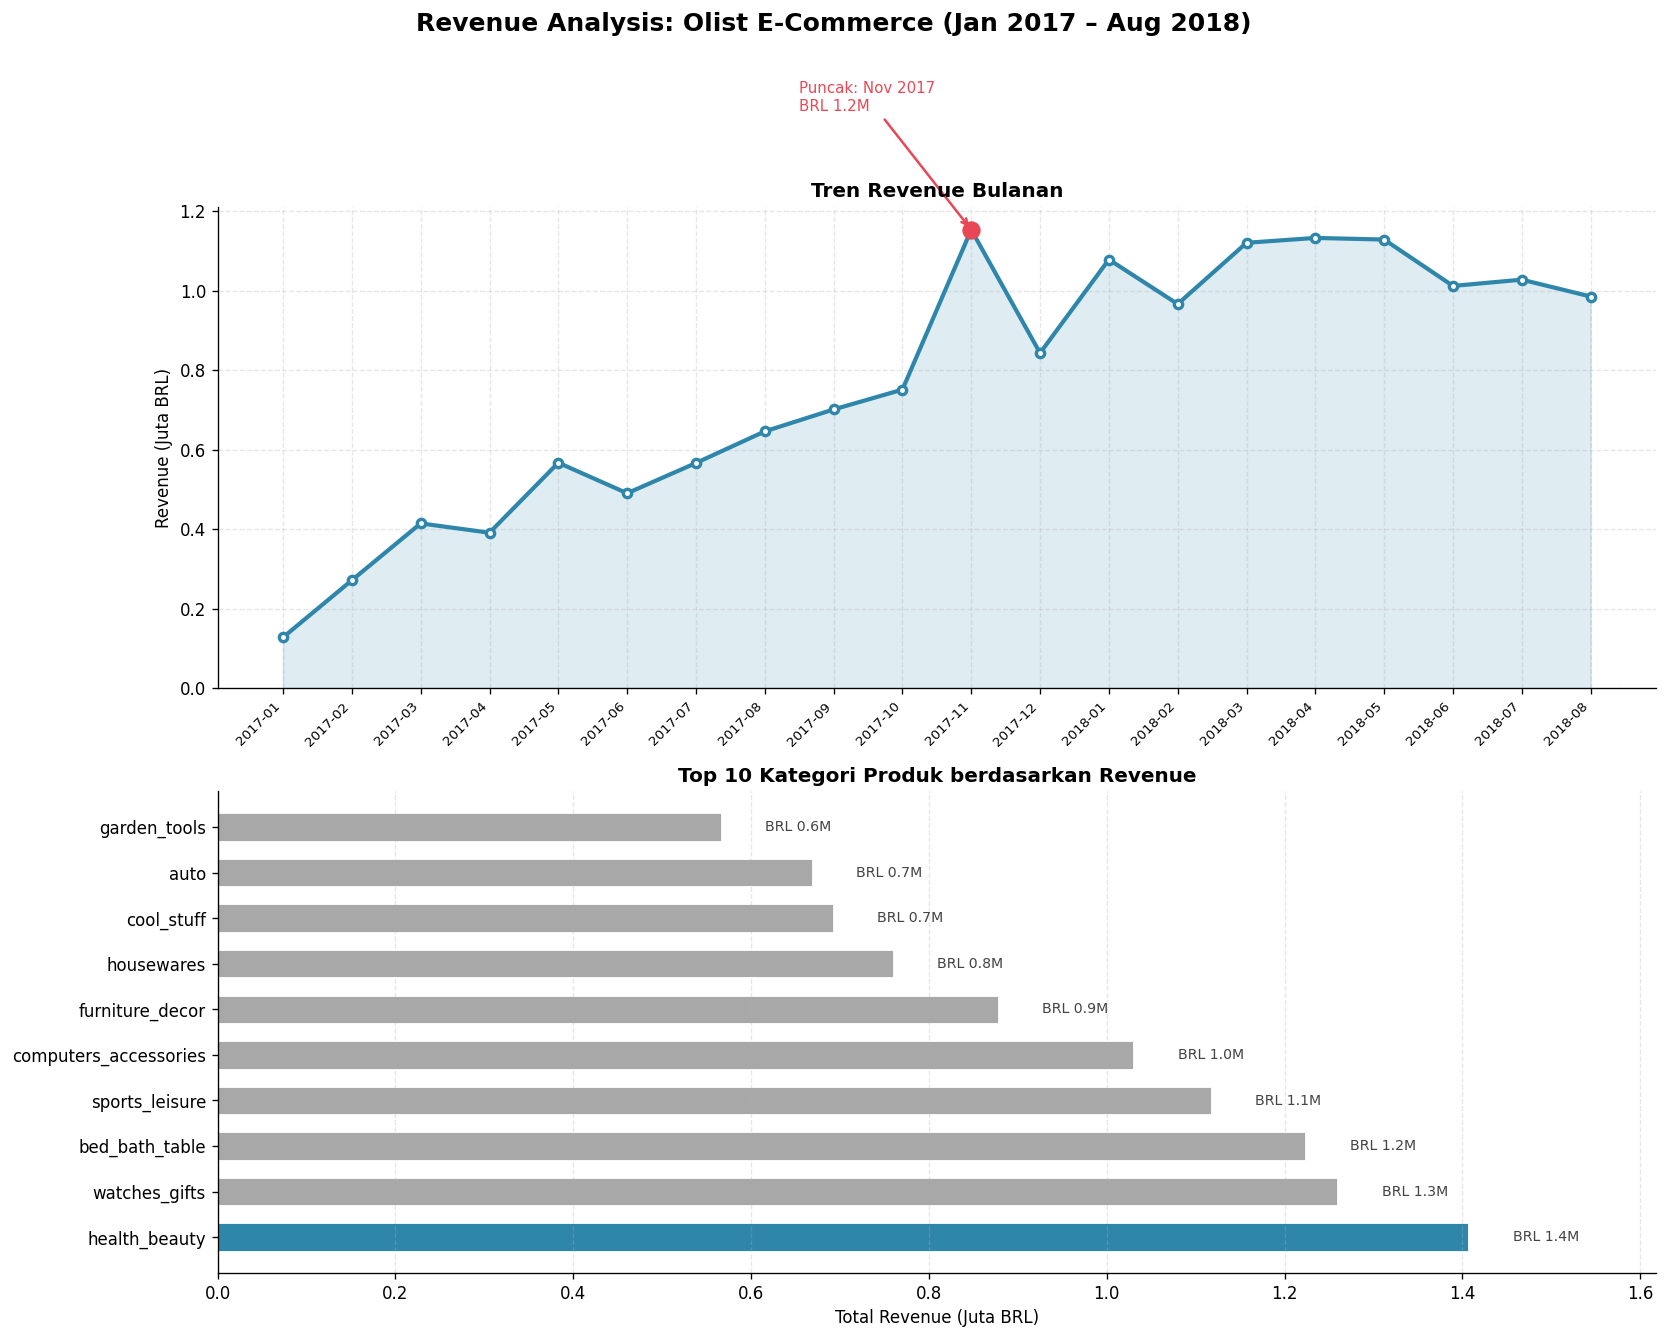

Visualisasi pertanyaan 1 disimpan sebagai viz_question1_revenue.png


In [27]:
# Persiapan data
top10_rev_cats = category_revenue.head(10).copy()

# Palette warna: bar pertama diberi warna aksen, sisanya warna netral
bar_colors = [COLOR_PRIMARY] + [COLOR_NEUTRAL] * 9

# Membuat figure dengan 2 subplot
fig, axes = plt.subplots(2, 1, figsize=(14, 11))
fig.suptitle('Revenue Analysis: Olist E-Commerce (Jan 2017 – Aug 2018)',
             fontsize=15, fontweight='bold', y=1.01)

# --- Plot 1: Tren Revenue Bulanan ---
ax1 = axes[0]

x_vals = range(len(monthly_revenue))

# Area chart untuk konteks visual
ax1.fill_between(x_vals, monthly_revenue['revenue'] / 1e6,
                 alpha=0.15, color=COLOR_PRIMARY)

# Line chart utama
ax1.plot(x_vals, monthly_revenue['revenue'] / 1e6,
         color=COLOR_PRIMARY, linewidth=2.5, marker='o',
         markersize=5, markerfacecolor='white', markeredgewidth=2)

# Menandai titik puncak (Black Friday Nov 2017)
peak_idx = monthly_revenue['revenue'].idxmax()
ax1.plot(peak_idx, monthly_revenue.loc[peak_idx, 'revenue'] / 1e6,
         'o', color=COLOR_ACCENT, markersize=10, zorder=5)
ax1.annotate(
    f"Puncak: Nov 2017\nBRL {monthly_revenue.loc[peak_idx, 'revenue']/1e6:.1f}M",
    xy=(peak_idx, monthly_revenue.loc[peak_idx, 'revenue'] / 1e6),
    xytext=(peak_idx - 2.5, monthly_revenue.loc[peak_idx, 'revenue'] / 1e6 + 0.3),
    fontsize=9, color=COLOR_ACCENT,
    arrowprops=dict(arrowstyle='->', color=COLOR_ACCENT, lw=1.5)
)

# Konfigurasi sumbu
ax1.set_xticks(x_vals)
ax1.set_xticklabels(monthly_revenue['yearmonth_str'], rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Revenue (Juta BRL)', fontsize=10)
ax1.set_title('Tren Revenue Bulanan', fontsize=12, fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

# Sumbu Y dimulai dari 0 sesuai prinsip integritas visualisasi
ax1.set_ylim(bottom=0)

# --- Plot 2: Top 10 Kategori Berdasarkan Revenue ---
ax2 = axes[1]

# Horizontal bar chart lebih mudah dibaca untuk label panjang
bars = ax2.barh(
    top10_rev_cats['product_category'],
    top10_rev_cats['total_revenue'] / 1e6,
    color=[COLOR_PRIMARY] + [COLOR_NEUTRAL] * 9,
    edgecolor='white', linewidth=0.5, height=0.6
)

# Menambahkan label nilai di ujung setiap bar (prinsip: label jelas)
for bar, val in zip(bars, top10_rev_cats['total_revenue'] / 1e6):
    ax2.text(val + 0.05, bar.get_y() + bar.get_height() / 2,
             f'BRL {val:.1f}M', va='center', fontsize=8.5, color='#444')

ax2.set_xlabel('Total Revenue (Juta BRL)', fontsize=10)
ax2.set_title('Top 10 Kategori Produk berdasarkan Revenue', fontsize=12, fontweight='bold')
ax2.set_xlim(right=top10_rev_cats['total_revenue'].max() / 1e6 * 1.15)

# Sumbu X dimulai dari 0 sesuai prinsip integritas visualisasi
ax2.set_xlim(left=0)

# Hapus grid pada sumbu Y karena tidak relevan untuk horizontal bar
ax2.yaxis.grid(False)
ax2.xaxis.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('viz_question1_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi pertanyaan 1 disimpan sebagai viz_question1_revenue.png')

### Pertanyaan 2: Distribusi Kepuasan Pelanggan per Kategori Produk

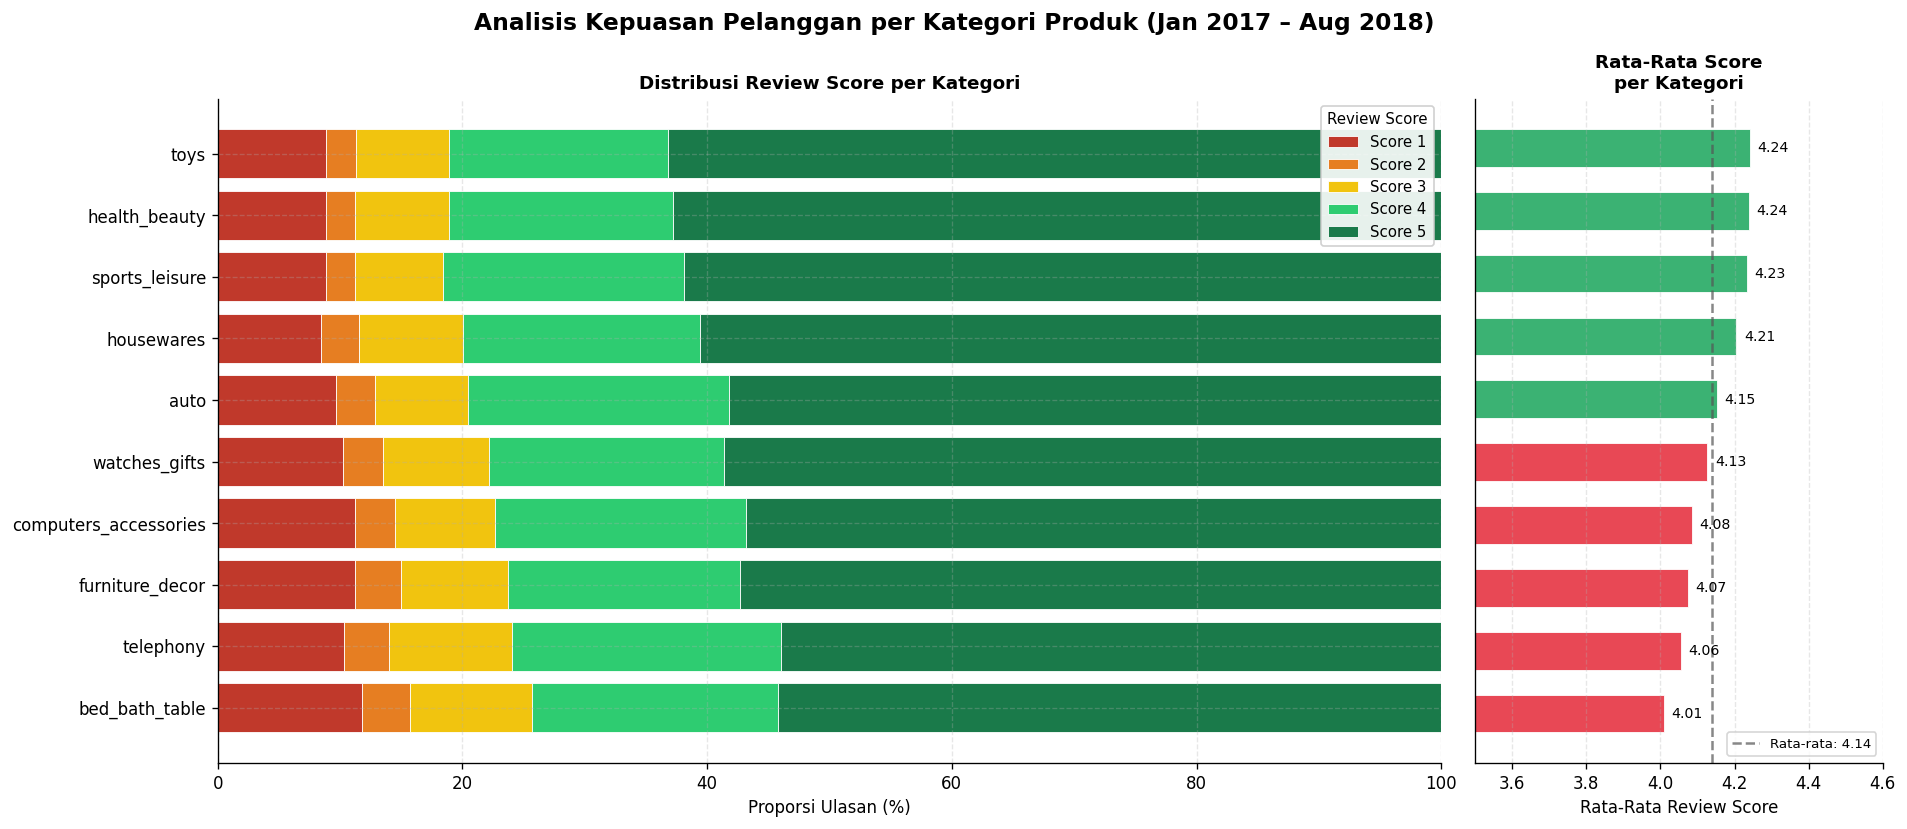

Visualisasi pertanyaan 2 disimpan sebagai viz_question2_review.png


In [28]:
# Persiapan data: hitung proporsi setiap skor (1-5) per kategori
score_by_cat = (
    df_top10
    .groupby(['product_category', 'review_score'])
    .size()
    .unstack(fill_value=0)
    .apply(lambda x: x / x.sum() * 100, axis=1)  # Konversi ke persentase
)

# Urutkan berdasarkan rata-rata skor (terendah di atas agar mudah dibaca)
sorted_cats = category_score['product_category'].tolist()
score_by_cat = score_by_cat.reindex(sorted_cats)

# Palet warna diverging: merah untuk skor rendah, hijau untuk skor tinggi
score_colors = {
    1: '#C0392B',  # Merah tua - sangat tidak puas
    2: '#E67E22',  # Oranye - tidak puas
    3: '#F1C40F',  # Kuning - netral
    4: '#2ECC71',  # Hijau muda - puas
    5: '#1A7A4A'   # Hijau tua - sangat puas
}

# Membuat figure
fig, axes = plt.subplots(1, 2, figsize=(16, 7),
                         gridspec_kw={'width_ratios': [3, 1]})
fig.suptitle('Analisis Kepuasan Pelanggan per Kategori Produk (Jan 2017 – Aug 2018)',
             fontsize=14, fontweight='bold')

# --- Plot 1: Stacked Bar Chart (Distribusi Skor per Kategori) ---
ax1 = axes[0]

bottom = np.zeros(len(score_by_cat))
for score in [1, 2, 3, 4, 5]:
    if score in score_by_cat.columns:
        values = score_by_cat[score].values
        bars = ax1.barh(
            score_by_cat.index,
            values,
            left=bottom,
            color=score_colors[score],
            label=f'Score {score}',
            edgecolor='white', linewidth=0.5
        )
        bottom += values

ax1.set_xlabel('Proporsi Ulasan (%)', fontsize=10)
ax1.set_title('Distribusi Review Score per Kategori', fontsize=11, fontweight='bold')
ax1.set_xlim(0, 100)
ax1.legend(loc='upper right', fontsize=9, title='Review Score',
           title_fontsize=9, framealpha=0.9)

# Menambahkan garis vertikal sebagai referensi kepuasan rata-rata
avg_score5_pct = (df_top10['review_score'] == 5).sum() / len(df_top10) * 100

# --- Plot 2: Rata-Rata Review Score per Kategori ---
ax2 = axes[1]

# Warna bar bergantung pada posisi relatif terhadap rata-rata keseluruhan
overall_avg = df_top10['review_score'].mean()
bar_colors_score = [
    COLOR_ACCENT if v < overall_avg else COLOR_SUCCESS
    for v in category_score['mean']
]

bars2 = ax2.barh(
    category_score['product_category'],
    category_score['mean'],
    color=bar_colors_score,
    edgecolor='white', linewidth=0.5, height=0.6
)

# Garis vertikal rata-rata keseluruhan sebagai referensi
ax2.axvline(x=overall_avg, color='#555', linestyle='--', linewidth=1.5, alpha=0.7,
            label=f'Rata-rata: {overall_avg:.2f}')

# Label nilai pada setiap bar
for bar, val in zip(bars2, category_score['mean']):
    ax2.text(val + 0.02, bar.get_y() + bar.get_height() / 2,
             f'{val:.2f}', va='center', fontsize=8.5)

ax2.set_xlabel('Rata-Rata Review Score', fontsize=10)
ax2.set_title('Rata-Rata Score\nper Kategori', fontsize=11, fontweight='bold')
ax2.set_xlim(3.5, 4.6)
ax2.legend(fontsize=8, loc='lower right')
ax2.set_yticks([])

plt.tight_layout()
plt.savefig('viz_question2_review.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi pertanyaan 2 disimpan sebagai viz_question2_review.png')

**Insight - Visualization & Explanatory Analysis:**
- **Visualisasi 1 (Revenue)**: Tren line chart mengonfirmasi pertumbuhan yang tidak linear — ada lonjakan tajam menuju November 2017, diikuti penurunan di Desember 2017–Januari 2018, kemudian recovery dan pertumbuhan stabil hingga Agustus 2018. Kategori `health_beauty` (BRL 1,4M) unggul signifikan dari kategori kedua `watches_gifts` (BRL 1,25M).
- **Visualisasi 2 (Kepuasan)**: Stacked bar chart memperlihatkan bahwa hampir semua kategori didominasi warna hijau (skor 4-5), namun `bed_bath_table` dan `telephony` memiliki proporsi warna merah (skor 1-2) yang lebih besar dibanding kategori lain — mengindikasikan ketidakpuasan yang lebih tersebar di kedua kategori ini.
- Penggunaan warna diverging (merah untuk skor rendah, hijau untuk skor tinggi) pada stacked bar chart memudahkan pembaca mengidentifikasi pola kepuasan secara intuitif sesuai prinsip desain visualisasi data.

## Analisis Lanjutan

Bagian ini menerapkan tiga teknik analisis lanjutan yang relevan dengan dataset e-commerce:
1. **RFM Analysis** — segmentasi pelanggan berdasarkan perilaku transaksi
2. **Geospatial Analysis** — distribusi geografis order di Brazil
3. **Clustering** — pengelompokan kategori produk berdasarkan performa bisnis

### Analisis Lanjutan 1: RFM Analysis (Customer Segmentation)

**Tujuan**: Mengelompokkan pelanggan berdasarkan tiga dimensi perilaku pembelian:
- **Recency (R)**: Seberapa baru pelanggan melakukan transaksi terakhir (dalam hari)
- **Frequency (F)**: Seberapa sering pelanggan melakukan transaksi
- **Monetary (M)**: Berapa total pengeluaran pelanggan

Analisis ini membantu tim marketing memprioritaskan segmen pelanggan yang paling bernilai.

In [29]:
# Menentukan tanggal referensi (1 hari setelah tanggal order terakhir dalam dataset)
reference_date = df_main['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f'Tanggal referensi RFM: {reference_date.date()}')

# Menghitung nilai RFM per pelanggan unik
rfm = (
    df_main
    .groupby('customer_unique_id')
    .agg(
        recency   = ('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
        frequency = ('order_id', 'count'),
        monetary  = ('total_payment', 'sum')
    )
    .reset_index()
)

print(f'\nJumlah pelanggan unik: {len(rfm):,}')
print('\nStatistik RFM:')
display(rfm[['recency', 'frequency', 'monetary']].describe().round(2))

Tanggal referensi RFM: 2018-08-30

Jumlah pelanggan unik: 93,104

Statistik RFM:


,recency,frequency,monetary
count,93104.00,93104.00,93104.00
mean,236.70,1.03,165.15
std,150.94,0.21,226.38
min,1.00,1.00,9.59
25%,114.00,1.00,63.04
50%,218.00,1.00,107.78
75%,345.00,1.00,182.50
max,602.00,15.00,13664.08


In [30]:
# Membuat skor RFM menggunakan metode quintile (pembagian menjadi 5 kelompok)
# Recency: skor tinggi (5) = baru belanja, skor rendah (1) = lama tidak belanja
# Frequency & Monetary: skor tinggi (5) = nilai tinggi

rfm['R_score'] = pd.qcut(rfm['recency'], q=5, labels=[5, 4, 3, 2, 1])
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
rfm['M_score'] = pd.qcut(rfm['monetary'], q=5, labels=[1, 2, 3, 4, 5])

# Konversi ke integer dan buat RFM combined score
rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)
rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm['RFM_total'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

# Segmentasi pelanggan berdasarkan kombinasi skor R dan F
def segment_customer(row):
    r, f = row['R_score'], row['F_score']
    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f <= 2:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2:
        return 'Lost Customers'
    else:
        return 'Need Attention'

rfm['segment'] = rfm.apply(segment_customer, axis=1)

# Ringkasan per segmen
segment_summary = (
    rfm.groupby('segment')
    .agg(
        n_customers  = ('customer_unique_id', 'count'),
        avg_recency  = ('recency', 'mean'),
        avg_frequency= ('frequency', 'mean'),
        avg_monetary = ('monetary', 'mean'),
        total_revenue= ('monetary', 'sum')
    )
    .round(2)
    .sort_values('total_revenue', ascending=False)
    .reset_index()
)

print('Ringkasan segmen pelanggan RFM:')
display(segment_summary)

Ringkasan segmen pelanggan RFM:


,segment,n_customers,avg_recency,avg_frequency,avg_monetary,total_revenue
0,At Risk,22079,392.65,1.05,166.98,3686761.05
1,Loyal Customers,18823,168.82,1.03,161.31,3036390.59
2,Champions,14960,90.22,1.09,176.92,2646760.88
3,New Customers,14985,90.88,1.00,163.42,2448921.30
4,Lost Customers,14883,393.43,1.00,162.68,2421165.78
5,Potential Loyalists,7374,220.24,1.00,154.04,1135875.84


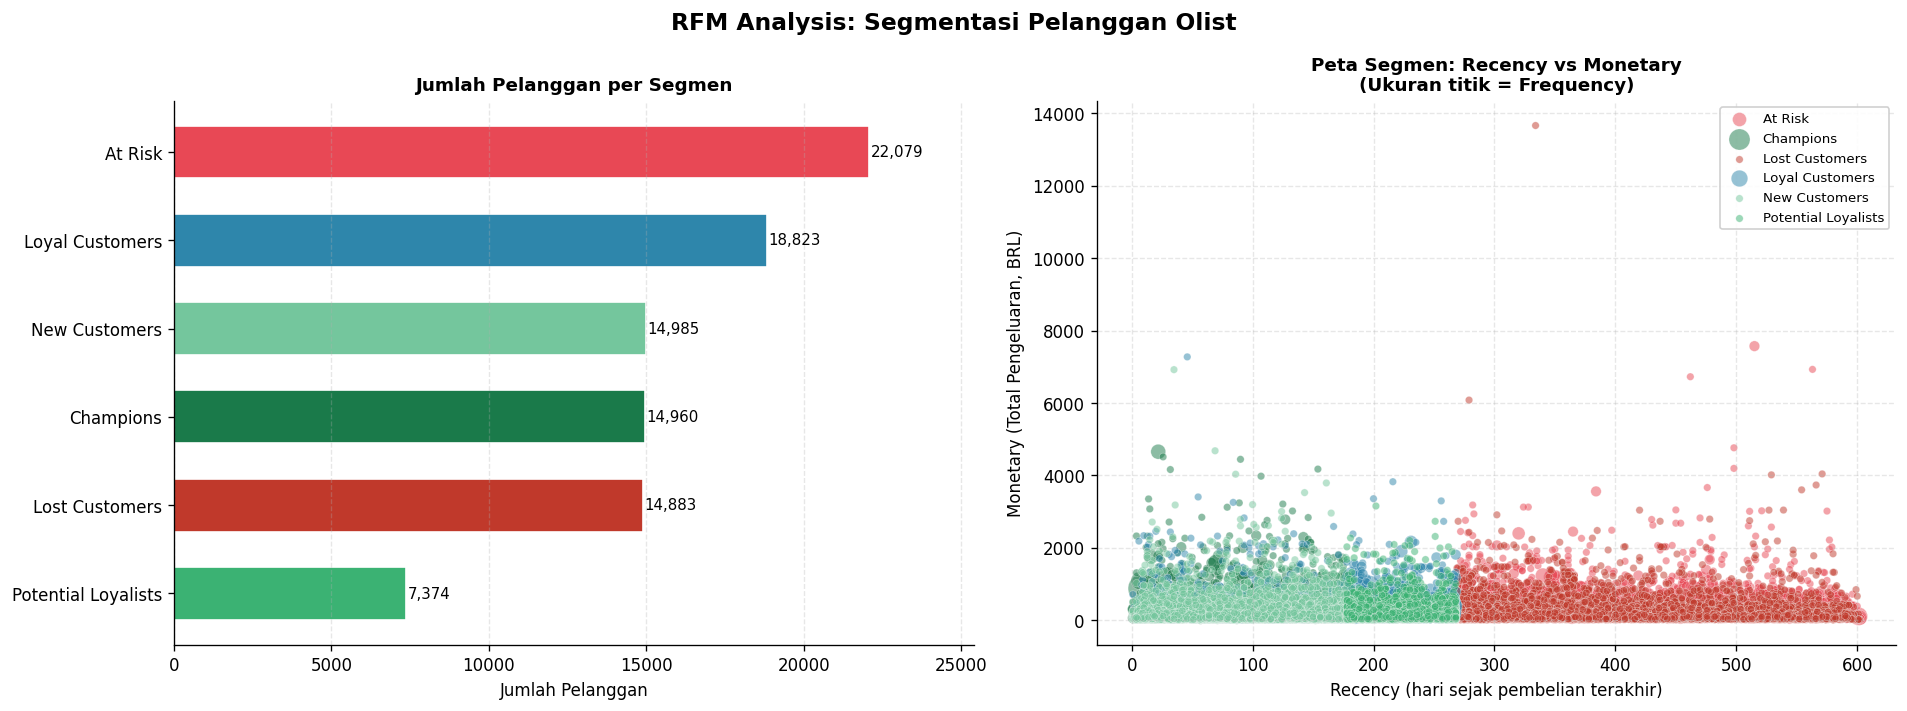

Visualisasi RFM disimpan sebagai viz_rfm_analysis.png


In [31]:
# Visualisasi RFM: Treemap-style bar chart dan scatter plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('RFM Analysis: Segmentasi Pelanggan Olist', fontsize=14, fontweight='bold')

# Palet warna per segmen
segment_colors = {
    'Champions'          : '#1A7A4A',
    'Loyal Customers'    : '#2E86AB',
    'Potential Loyalists': '#3BB273',
    'New Customers'      : '#74C69D',
    'Need Attention'     : '#F4A261',
    'At Risk'            : '#E84855',
    'Lost Customers'     : '#C0392B'
}

# --- Plot 1: Jumlah Pelanggan per Segmen ---
ax1 = axes[0]
sorted_seg = segment_summary.sort_values('n_customers', ascending=True)
colors_seg = [segment_colors.get(s, COLOR_NEUTRAL) for s in sorted_seg['segment']]

bars = ax1.barh(sorted_seg['segment'], sorted_seg['n_customers'],
                color=colors_seg, edgecolor='white', height=0.6)

for bar, val in zip(bars, sorted_seg['n_customers']):
    ax1.text(val + 50, bar.get_y() + bar.get_height() / 2,
             f'{val:,}', va='center', fontsize=9)

ax1.set_xlabel('Jumlah Pelanggan', fontsize=10)
ax1.set_title('Jumlah Pelanggan per Segmen', fontsize=11, fontweight='bold')
ax1.set_xlim(left=0, right=sorted_seg['n_customers'].max() * 1.15)
ax1.yaxis.grid(False)

# --- Plot 2: Scatter Plot Recency vs Monetary (ukuran titik = frequency) ---
ax2 = axes[1]

for segment, group in rfm.groupby('segment'):
    ax2.scatter(
        group['recency'],
        group['monetary'],
        c=segment_colors.get(segment, COLOR_NEUTRAL),
        s=group['frequency'] * 20,
        alpha=0.5, label=segment, edgecolors='white', linewidths=0.3
    )

ax2.set_xlabel('Recency (hari sejak pembelian terakhir)', fontsize=10)
ax2.set_ylabel('Monetary (Total Pengeluaran, BRL)', fontsize=10)
ax2.set_title('Peta Segmen: Recency vs Monetary\n(Ukuran titik = Frequency)', fontsize=11, fontweight='bold')
ax2.legend(fontsize=8, loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.savefig('viz_rfm_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi RFM disimpan sebagai viz_rfm_analysis.png')

### Analisis Lanjutan 2: Geospatial Analysis

**Tujuan**: Menganalisis distribusi geografis order di seluruh negara bagian Brazil untuk mengidentifikasi konsentrasi pasar dan peluang ekspansi.

Analisis ini menggunakan library `folium` untuk membuat peta interaktif dan `seaborn` untuk visualisasi statis distribusi per negara bagian.

In [32]:
# Menghitung jumlah order dan total revenue per negara bagian pelanggan
state_stats = (
    df_main
    .groupby('customer_state')
    .agg(
        n_orders     = ('order_id', 'count'),
        total_revenue= ('total_payment', 'sum'),
        avg_score    = ('review_score', 'mean')
    )
    .reset_index()
    .sort_values('n_orders', ascending=False)
)

print('Top 10 negara bagian berdasarkan jumlah order:')
display(state_stats.head(10))

Top 10 negara bagian berdasarkan jumlah order:


,customer_state,n_orders,total_revenue,avg_score
25,SP,40406,5756706.26,4.246727
18,RJ,12310,2046698.14,3.965577
10,MG,11319,1814317.79,4.193227
22,RS,5328,858904.29,4.185311
17,PR,4903,779319.58,4.240984
23,SC,3537,592707.68,4.134188
4,BA,3253,590949.59,3.929324
6,DF,2074,344946.06,4.135659
7,ES,1992,316690.84,4.078840
8,GO,1950,333238.10,4.101599


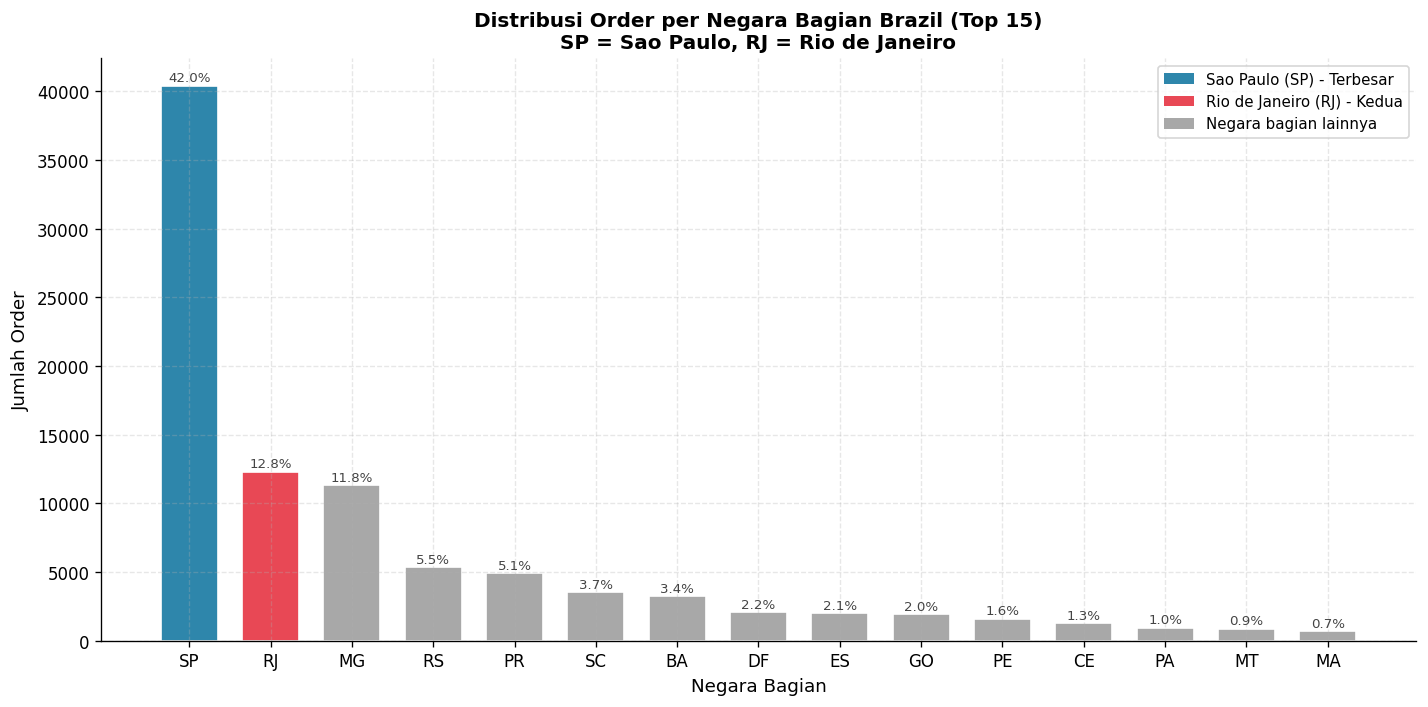

In [33]:
# Visualisasi bar chart distribusi order per negara bagian (top 15)
top15_states = state_stats.head(15)

fig, ax = plt.subplots(figsize=(12, 6))

bar_colors_state = [COLOR_PRIMARY if s == 'SP' else
                    COLOR_ACCENT  if s == 'RJ' else
                    COLOR_NEUTRAL for s in top15_states['customer_state']]

bars = ax.bar(top15_states['customer_state'], top15_states['n_orders'],
              color=bar_colors_state, edgecolor='white', width=0.7)

# Menambahkan label persentase di atas setiap bar
total_orders = state_stats['n_orders'].sum()
for bar, n in zip(bars, top15_states['n_orders']):
    pct = n / total_orders * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=8, color='#444')

ax.set_xlabel('Negara Bagian', fontsize=11)
ax.set_ylabel('Jumlah Order', fontsize=11)
ax.set_title('Distribusi Order per Negara Bagian Brazil (Top 15)\nSP = Sao Paulo, RJ = Rio de Janeiro',
             fontsize=12, fontweight='bold')
ax.set_ylim(bottom=0)

# Legend manual untuk highlight
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLOR_PRIMARY, label='Sao Paulo (SP) - Terbesar'),
    Patch(facecolor=COLOR_ACCENT,  label='Rio de Janeiro (RJ) - Kedua'),
    Patch(facecolor=COLOR_NEUTRAL, label='Negara bagian lainnya')
]
ax.legend(handles=legend_elements, fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('viz_geospatial_bar.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
# Membuat peta interaktif heatmap menggunakan folium
# Menggabungkan koordinat pelanggan melalui kode pos
customer_geo = (
    df_customers[['customer_unique_id', 'customer_zip_code_prefix']]
    .merge(df_geo_unique.rename(columns={'geolocation_zip_code_prefix': 'customer_zip_code_prefix'}),
           on='customer_zip_code_prefix', how='left')
    .dropna(subset=['geolocation_lat', 'geolocation_lng'])
)

# Gabungkan dengan data order untuk mendapatkan pelanggan aktif saja
active_customer_ids = df_main['customer_unique_id'].unique()
customer_geo_active = customer_geo[
    customer_geo['customer_unique_id'].isin(active_customer_ids)
]

# Batasi jumlah titik untuk performa (ambil sampel acak 10.000 titik)
sample_geo = customer_geo_active.sample(
    n=min(10000, len(customer_geo_active)),
    random_state=42
)

# Membuat peta folium dengan pusat di Brazil
m = folium.Map(
    location=[-14.0, -51.0],  # Koordinat pusat Brazil
    zoom_start=4,
    tiles='CartoDB positron'   # Tile peta yang bersih
)

# Menambahkan heatmap layer
heat_data = [
    [row['geolocation_lat'], row['geolocation_lng']]
    for _, row in sample_geo.iterrows()
]

HeatMap(
    heat_data,
    radius=8,
    blur=10,
    min_opacity=0.3,
    gradient={0.2: '#3B4CC0', 0.5: '#88BEDC', 0.75: '#F7E589', 1.0: '#B40426'}
).add_to(m)

# Menambahkan judul pada peta
title_html = '''
    <div style="position: fixed; top: 10px; left: 50%; transform: translateX(-50%);
                background: white; padding: 8px 16px; border-radius: 4px;
                border: 1px solid #ccc; font-size: 14px; font-weight: bold;
                z-index: 1000; box-shadow: 2px 2px 6px rgba(0,0,0,0.2);">
        Peta Distribusi Pelanggan Olist di Brazil (Jan 2017 - Aug 2018)
    </div>
'''
m.get_root().html.add_child(folium.Element(title_html))

# Simpan sebagai HTML interaktif
m.save('viz_geospatial_map.html')
print(f'Peta interaktif disimpan sebagai viz_geospatial_map.html')
print(f'Jumlah titik pada peta: {len(sample_geo):,}')

# Tampilkan peta di notebook
display(m)

Peta interaktif disimpan sebagai viz_geospatial_map.html
Jumlah titik pada peta: 10,000


### Analisis Lanjutan 3: Clustering Kategori Produk

**Tujuan**: Mengelompokkan kategori produk ke dalam klaster berdasarkan kombinasi dua dimensi performa bisnis:
- **Revenue** (total pendapatan)
- **Kepuasan pelanggan** (rata-rata review score)

Metode yang digunakan adalah **manual binning** (tanpa machine learning) menggunakan nilai median sebagai threshold pembagian klaster.

In [35]:
# Menyiapkan data kategori untuk clustering
# Ambil semua kategori dengan minimal 50 order untuk representasi yang cukup
category_cluster_data = (
    df_main[df_main['product_category'] != 'unknown']
    .groupby('product_category')
    .agg(
        total_revenue = ('total_payment', 'sum'),
        avg_score     = ('review_score', 'mean'),
        n_orders      = ('order_id', 'count')
    )
    .reset_index()
)

# Filter kategori dengan minimal 50 order
category_cluster_data = category_cluster_data[
    category_cluster_data['n_orders'] >= 50
].copy()

# Menggunakan nilai median sebagai threshold untuk membagi menjadi 4 kuadran
median_revenue = category_cluster_data['total_revenue'].median()
median_score   = category_cluster_data['avg_score'].median()

print(f'Median total revenue: BRL {median_revenue:,.0f}')
print(f'Median rata-rata skor: {median_score:.3f}')

# Membuat label cluster berdasarkan posisi relatif terhadap median
def assign_cluster(row):
    high_rev   = row['total_revenue'] >= median_revenue
    high_score = row['avg_score'] >= median_score
    if high_rev and high_score:
        return 'Stars'           # Revenue tinggi, kepuasan tinggi
    elif high_rev and not high_score:
        return 'Cash Cows'       # Revenue tinggi, kepuasan rendah
    elif not high_rev and high_score:
        return 'Rising Stars'    # Revenue rendah, kepuasan tinggi
    else:
        return 'Underperformers' # Revenue rendah, kepuasan rendah

category_cluster_data['cluster'] = category_cluster_data.apply(assign_cluster, axis=1)

# Ringkasan distribusi per klaster
cluster_summary = (
    category_cluster_data.groupby('cluster')
    .agg(n_categories=('product_category', 'count'))
    .reset_index()
)
print('\nJumlah kategori per cluster:')
display(cluster_summary)

Median total revenue: BRL 85,735
Median rata-rata skor: 4.194

Jumlah kategori per cluster:


,cluster,n_categories
0,Cash Cows,14
1,Rising Stars,14
2,Stars,15
3,Underperformers,14


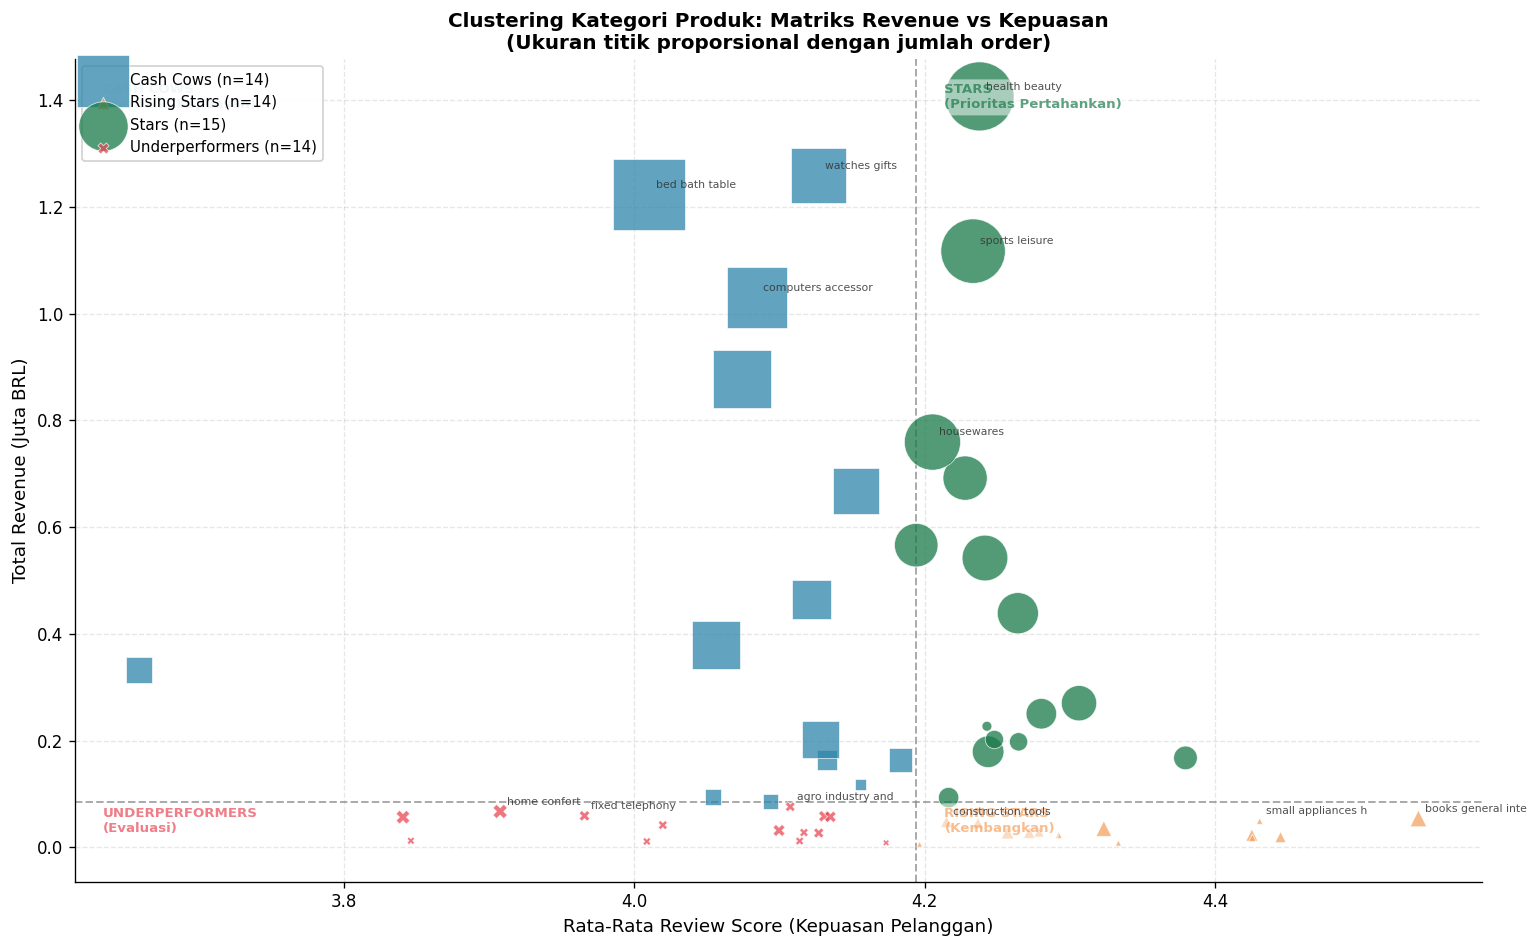

Visualisasi clustering disimpan sebagai viz_clustering.png


In [36]:
# Visualisasi cluster: Scatter plot 4 kuadran
fig, ax = plt.subplots(figsize=(13, 8))

cluster_colors = {
    'Stars'          : '#1A7A4A',
    'Cash Cows'      : '#2E86AB',
    'Rising Stars'   : '#F4A261',
    'Underperformers': '#E84855'
}

cluster_markers = {
    'Stars'          : 'o',
    'Cash Cows'      : 's',
    'Rising Stars'   : '^',
    'Underperformers': 'X'
}

for cluster_name, group in category_cluster_data.groupby('cluster'):
    ax.scatter(
        group['avg_score'],
        group['total_revenue'] / 1e6,
        c=cluster_colors[cluster_name],
        marker=cluster_markers[cluster_name],
        s=group['n_orders'] / 5,  # Ukuran titik proporsional dengan jumlah order
        label=f'{cluster_name} (n={len(group)})',
        alpha=0.75, edgecolors='white', linewidths=0.5, zorder=3
    )

# Garis threshold median sebagai pembatas kuadran
ax.axvline(x=median_score,   color='#888', linestyle='--', linewidth=1.2, alpha=0.7, zorder=2)
ax.axhline(y=median_revenue / 1e6, color='#888', linestyle='--', linewidth=1.2, alpha=0.7, zorder=2)

# Label kuadran di pojok setiap area
ax_xlim  = ax.get_xlim()
ax_ylim  = ax.get_ylim()
text_offset_x = (ax_xlim[1] - ax_xlim[0]) * 0.02
text_offset_y = (ax_ylim[1] - ax_ylim[0]) * 0.03

quadrant_labels = [
    (median_score + text_offset_x, ax_ylim[1] - text_offset_y*2, 'STARS\n(Prioritas Pertahankan)', 'left',  '#1A7A4A'),
    (ax_xlim[0]   + text_offset_x, ax_ylim[1] - text_offset_y*2, 'CASH COWS\n(Perbaiki Kepuasan)',  'left',  '#2E86AB'),
    (median_score + text_offset_x, ax_ylim[0] + text_offset_y*2, 'RISING STARS\n(Kembangkan)',      'left',  '#F4A261'),
    (ax_xlim[0]   + text_offset_x, ax_ylim[0] + text_offset_y*2, 'UNDERPERFORMERS\n(Evaluasi)',     'left',  '#E84855'),
]

for qx, qy, qlabel, qha, qcolor in quadrant_labels:
    ax.text(qx, qy, qlabel, ha=qha, fontsize=8, color=qcolor,
            fontweight='bold', alpha=0.7,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.5, edgecolor='none'))

# Label beberapa kategori penting (top 5 per cluster untuk keterbacaan)
top_to_label = (
    category_cluster_data
    .sort_values('total_revenue', ascending=False)
    .groupby('cluster')
    .head(3)
)

for _, row in top_to_label.iterrows():
    short_name = row['product_category'].replace('_', ' ')[:18]
    ax.annotate(
        short_name,
        xy=(row['avg_score'], row['total_revenue'] / 1e6),
        xytext=(4, 4), textcoords='offset points',
        fontsize=6.5, color='#333', alpha=0.85
    )

ax.set_xlabel('Rata-Rata Review Score (Kepuasan Pelanggan)', fontsize=11)
ax.set_ylabel('Total Revenue (Juta BRL)', fontsize=11)
ax.set_title('Clustering Kategori Produk: Matriks Revenue vs Kepuasan\n(Ukuran titik proporsional dengan jumlah order)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.savefig('viz_clustering.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi clustering disimpan sebagai viz_clustering.png')

**Insight - Analisis Lanjutan:**

**RFM Analysis:**
- Dari **93.104 pelanggan unik**, segmen terbesar adalah **`At Risk`** (22.079 pelanggan, 23,7%) — pelanggan yang dulu aktif tetapi sudah lama tidak bertransaksi (rata-rata recency 393 hari). Ini sinyal serius tentang rendahnya tingkat retensi.
- Rata-rata `frequency` untuk seluruh segmen hanya **1,00–1,09** — hampir semua pelanggan hanya pernah bertransaksi **satu kali**. Ini adalah karakteristik umum e-commerce general yang belum berhasil membangun loyalitas.
- Segmen **`Champions`** (14.960 pelanggan) memiliki rata-rata recency 90 hari dan monetary BRL 176,92 — mereka adalah pelanggan paling aktif dan paling bernilai, namun hanya 16,1% dari total basis pelanggan.
- Segmen **`At Risk`** justru memiliki **total revenue tertinggi** (BRL 3,69M) karena jumlahnya paling besar — menjadikannya prioritas utama untuk program win-back.

**Geospatial Analysis:**
- **Sao Paulo (SP)** mendominasi secara luar biasa dengan **40.406 order (42,0% dari total nasional)** dan revenue BRL 5,76M. Jauh melampaui posisi kedua Rio de Janeiro (RJ) dengan 12.310 order (12,8%).
- Lima negara bagian teratas (SP, RJ, MG, RS, PR) menyumbang lebih dari **76% total order** — mengindikasikan konsentrasi pasar yang sangat tinggi di kawasan tenggara-selatan Brazil.
- Kepuasan rata-rata bervariasi antar negara bagian: SP memiliki skor tertinggi (4,25) sementara BA (Bahia) memiliki skor terendah (3,93) di antara 10 negara bagian terbesar — mengindikasikan potensi masalah layanan atau logistik di wilayah tertentu.

**Clustering Kategori Produk:**
- Dari 57 kategori yang memenuhi syarat (minimal 50 order), terdistribusi hampir merata: **Stars (15)**, **Cash Cows (14)**, **Rising Stars (14)**, dan **Underperformers (14)** kategori.
- Threshold clustering: median revenue BRL 85.735 dan median skor 4,194.
- Kategori `health_beauty` dan `watches_gifts` masuk kuadran **Stars** — revenue tinggi sekaligus kepuasan tinggi, menjadikan keduanya prioritas utama untuk dipertahankan dan dikembangkan.

## Conclusion & Recommendation

**Conclusion Pertanyaan 1 — Tren Revenue dan Kategori Teratas:**

Revenue platform Olist menunjukkan **pertumbuhan yang konsisten** sepanjang Januari 2017 hingga Agustus 2018, dengan total 20 bulan data yang dianalisis. Revenue bulanan tumbuh dari BRL 127.546 (Januari 2017) hingga mencapai puncaknya di **BRL 1.153.528 pada November 2017** — lonjakan hampir 9x lipat yang sangat kemungkinan dipicu oleh event **Black Friday**. Rata-rata revenue bulanan selama periode analisis adalah BRL 768.794. Setelah puncak November 2017, revenue mengalami normalisasi dan kemudian stabil di kisaran BRL 800 ribu hingga 1 juta sepanjang semester pertama 2018. Kategori produk dengan kontribusi revenue tertinggi adalah **`health_beauty`** (BRL 1.406.712 dari 8.571 order), **`watches_gifts`** (BRL 1.259.157), dan **`bed_bath_table`** (BRL 1.223.393 dari 9.162 order — volume order terbanyak).

---

**Conclusion Pertanyaan 2 — Kepuasan Pelanggan per Kategori:**

Secara keseluruhan, platform Olist memiliki rata-rata skor kepuasan **4,156 dari 5,0** yang cukup baik, dengan **59,2% pelanggan memberikan skor sempurna (5)**. Namun terdapat **9,7% pelanggan yang sangat tidak puas (skor 1)** — kelompok yang berpotensi memberikan ulasan negatif di publik. Dari 10 kategori produk dengan volume order tertinggi, **`bed_bath_table`** memiliki rata-rata kepuasan terendah (4,010) diikuti **`telephony`** (4,056) dan **`furniture_decor`** (4,074). Ketiga kategori ini memiliki standar deviasi yang lebih tinggi (>1,34) dibanding kategori lain, mengindikasikan ketidakkonsistenan pengalaman pelanggan. Sebaliknya, kategori **`toys`** (4,241), **`health_beauty`** (4,238), dan **`sports_leisure`** (4,233) secara konsisten memiliki kepuasan tertinggi.

**Rekomendasi Action Item:**

1. **Maksimalkan Event Musiman (Black Friday)**: Lonjakan revenue November 2017 hingga BRL 1,15M — hampir 45% di atas rata-rata bulanan — membuktikan potensi besar event musiman. Olist perlu mempersiapkan infrastruktur, stok, dan kapasitas logistik minimal **2 bulan sebelum** setiap event serupa. Fokus promosi pada kategori top performer (`health_beauty`, `watches_gifts`) yang terbukti memiliki revenue tinggi sekaligus kepuasan pelanggan yang baik.

2. **Program Perbaikan Kualitas untuk `bed_bath_table` dan `telephony`**: Kedua kategori ini memiliki kepuasan terendah (4,01 dan 4,06) meski volume order-nya termasuk tertinggi. Langkah yang dapat diambil: (a) lakukan audit seller di kedua kategori tersebut, (b) terapkan SLA pengiriman yang lebih ketat untuk produk berukuran besar seperti furnitur dan kasur, (c) tambahkan program proteksi produk dan garansi untuk meningkatkan kepercayaan pembeli.

3. **Program Win-Back untuk Segmen `At Risk`**: Dengan **22.079 pelanggan** yang tidak lagi aktif (rata-rata 393 hari sejak transaksi terakhir) dan total revenue historis BRL 3,69M, segmen ini adalah prioritas utama. Kampanye reaktivasi berupa personalized email marketing dengan voucher diskon atau free shipping dapat efektif untuk menarik mereka kembali sebelum sepenuhnya beralih ke platform lain.

4. **Membangun Loyalitas pada `New Customers` dan `Potential Loyalists`**: Fakta bahwa hampir semua pelanggan (rata-rata frequency 1,00–1,09) hanya bertransaksi **satu kali** menunjukkan Olist belum berhasil membangun repeat purchase. Program loyalitas seperti cashback pembelian kedua, poin reward, atau membership tier dapat secara efektif mendorong pelanggan baru (14.985 orang) dan potential loyalists (7.374 orang) untuk melakukan transaksi berikutnya.

5. **Ekspansi Pasar ke Luar Kawasan Tenggara**: Dengan SP+RJ+MG menyumbang lebih dari 66% total order, masih terdapat potensi besar di negara bagian lain. Rekrut seller lokal di negara bagian Bahia (BA), Goiás (GO), dan Pará (PA) yang saat ini underserved namun memiliki populasi besar — sekaligus investigasi mengapa kepuasan pelanggan di BA (3,93) lebih rendah dari rata-rata nasional.